<a href="https://colab.research.google.com/github/psychic-coder/BlogApp/blob/main/Real_or_Fake_Fake_Job_Posting_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install kaggle
!pip install wordcloud
!pip install textblob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

print("All libraries imported successfully!")

All libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
from google.colab import files
uploaded = files.upload()


!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d shivamb/real-or-fake-fake-jobposting-prediction

# Unzip the dataset
!unzip -q real-or-fake-fake-jobposting-prediction.zip

print("Dataset downloaded and extracted successfully!")

Saving fake_job_postings.csv to fake_job_postings (1).csv
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
unzip:  cannot find or open real-or-fake-fake-jobposting-prediction.zip, real-or-fake-fake-jobpost

In [ ]:
df = pd.read_csv('fake_job_postings.csv')

print("Dataset shape:", df.shape)
print("\nDataset columns:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset shape: (17880, 18)

Dataset columns:
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

First few rows:


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("Missing values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("Target variable distribution:")
print(df['fraudulent'].value_counts())
print("\nPercentage distribution:")
print(df['fraudulent'].value_counts(normalize=True) * 100)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  ob

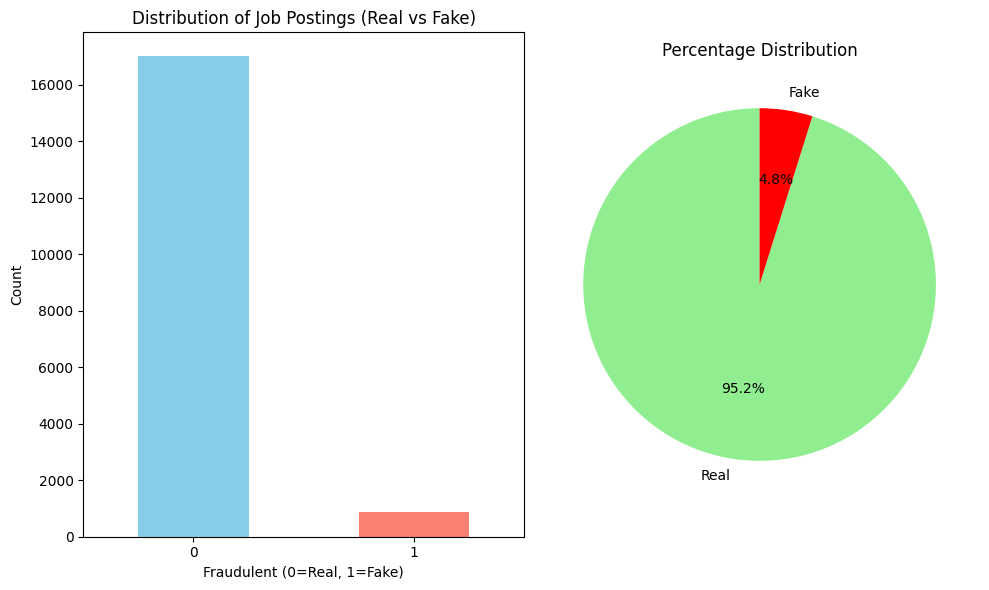

In [ ]:
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
df['fraudulent'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Job Postings (Real vs Fake)')
plt.xlabel('Fraudulent (0=Real, 1=Fake)')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
colors = ['lightgreen', 'red']
plt.pie(df['fraudulent'].value_counts(), labels=['Real', 'Fake'], autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Percentage Distribution')

plt.tight_layout()
plt.show()

In [ ]:
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']
for col in text_columns:
    df[col] = df[col].fillna('')

# Create a combined text feature
df['combined_text'] = df['title'] + ' ' + df['company_profile'] + ' ' + df['description'] + ' ' + df['requirements'] + ' ' + df['benefits']

print("Combined text feature created!")
print("Sample combined text:")
print(df['combined_text'].iloc[0][:500] + "...")

Combined text feature created!
Sample combined text:
Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributor...


In [ ]:
def preprocess_text(text):

    text = text.lower()


    text = re.sub(r'[^a-zA-Z\s]', '', text)


    text = re.sub(r'\s+', ' ', text).strip()


    tokens = text.split()


    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]


    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return ' '.join(tokens)


sample_text = df['combined_text'].iloc[0]
print("Original text sample:")
print(sample_text[:200])
print("\nPreprocessed text sample:")
print(preprocess_text(sample_text)[:200])

Original text sample:
Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have

Preprocessed text sample:
marketing intern food weve created groundbreaking awardwinning cooking site support connect celebrate home cook give everything need one placewe top editorial business engineering team focused using t


In [ ]:
print("Starting text preprocessing...")
df['processed_text'] = df['combined_text'].apply(preprocess_text)
print("Text preprocessing completed!")

print(f"Original text length: {len(df['combined_text'].iloc[0])}")
print(f"Processed text length: {len(df['processed_text'].iloc[0])}")

Starting text preprocessing...
Text preprocessing completed!
Original text length: 2662
Processed text length: 2003


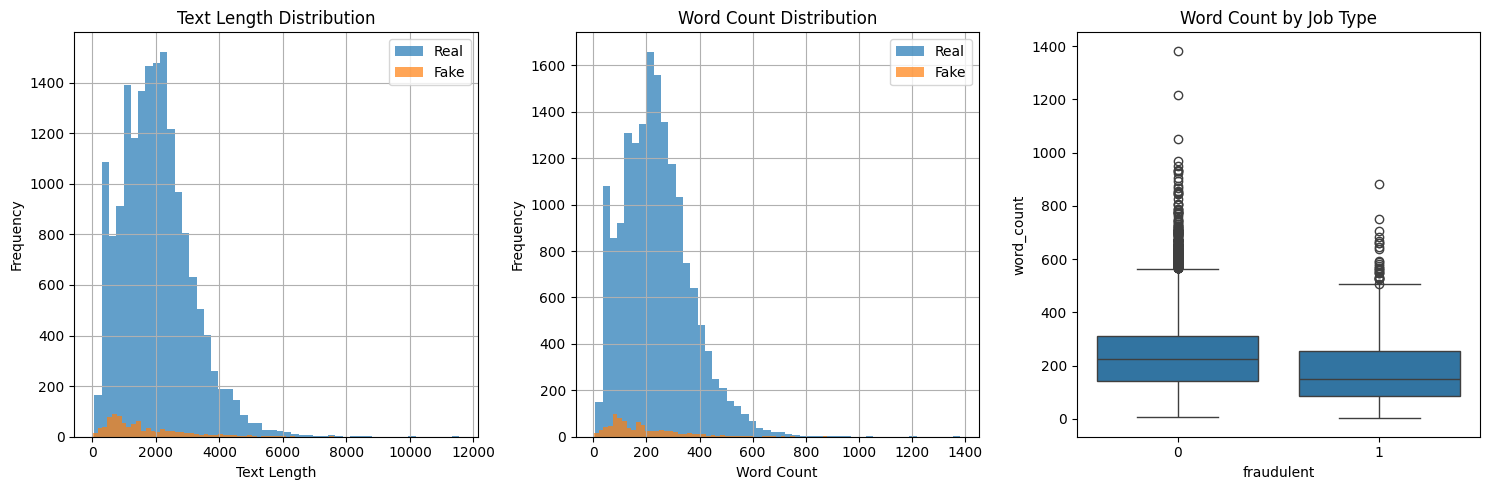

In [ ]:
df['text_length'] = df['processed_text'].apply(len)
df['word_count'] = df['processed_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
df[df['fraudulent'] == 0]['text_length'].hist(alpha=0.7, label='Real', bins=50)
df[df['fraudulent'] == 1]['text_length'].hist(alpha=0.7, label='Fake', bins=50)
plt.title('Text Length Distribution')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 3, 2)
df[df['fraudulent'] == 0]['word_count'].hist(alpha=0.7, label='Real', bins=50)
df[df['fraudulent'] == 1]['word_count'].hist(alpha=0.7, label='Fake', bins=50)
plt.title('Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 3, 3)
sns.boxplot(x='fraudulent', y='word_count', data=df)
plt.title('Word Count by Job Type')

plt.tight_layout()
plt.show()

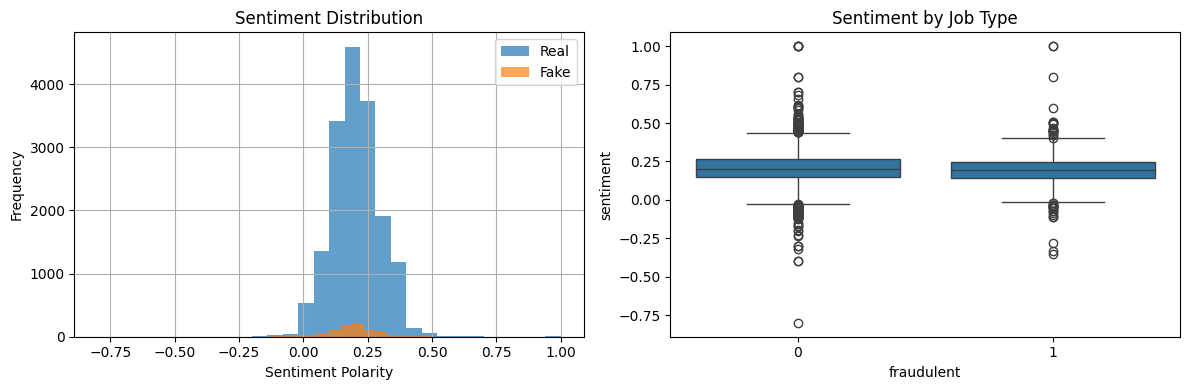

In [ ]:
def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

df['sentiment'] = df['processed_text'].apply(get_sentiment)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df[df['fraudulent'] == 0]['sentiment'].hist(alpha=0.7, label='Real', bins=30)
df[df['fraudulent'] == 1]['sentiment'].hist(alpha=0.7, label='Fake', bins=30)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(x='fraudulent', y='sentiment', data=df)
plt.title('Sentiment by Job Type')

plt.tight_layout()
plt.show()

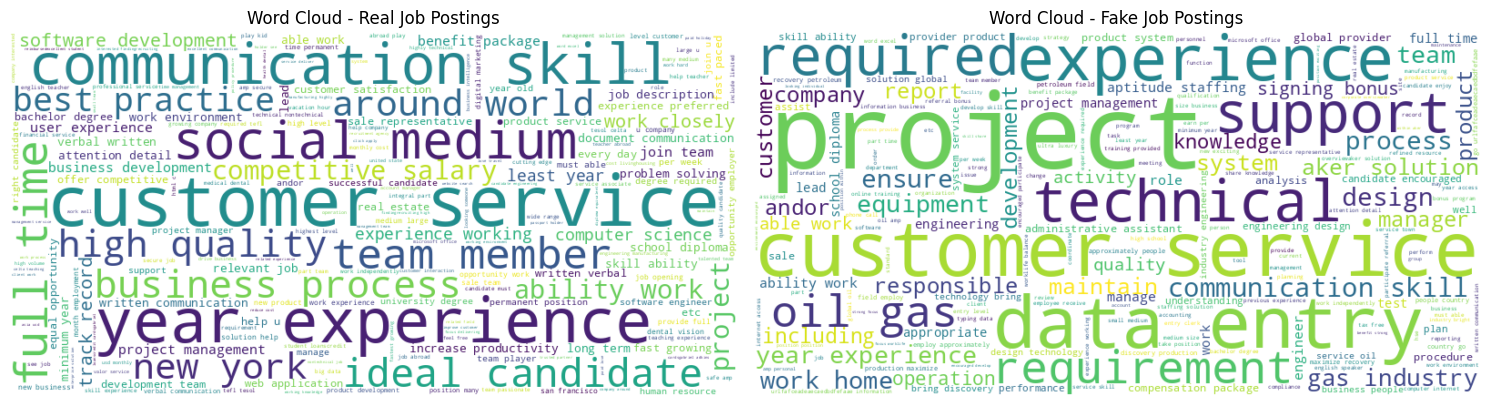

In [ ]:
real_text = ' '.join(df[df['fraudulent'] == 0]['processed_text'])
fake_text = ' '.join(df[df['fraudulent'] == 1]['processed_text'])

plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
wordcloud_real = WordCloud(width=800, height=400, background_color='white').generate(real_text)
plt.imshow(wordcloud_real, interpolation='bilinear')
plt.title('Word Cloud - Real Job Postings')
plt.axis('off')

plt.subplot(1, 2, 2)
wordcloud_fake = WordCloud(width=800, height=400, background_color='white').generate(fake_text)
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.title('Word Cloud - Fake Job Postings')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_tfidf = tfidf.fit_transform(df['processed_text'])


X_combined = pd.DataFrame(X_tfidf.toarray())
X_combined['word_count'] = df['word_count']
X_combined['sentiment'] = df['sentiment']


X_combined.columns = X_combined.columns.astype(str)

y = df['fraudulent']

print("Feature matrix shape:", X_combined.shape)
print("Target variable shape:", y.shape)
print("Column names type:", type(X_combined.columns[0]))
print("Sample column names:", X_combined.columns[:5].tolist())

Feature matrix shape: (17880, 5002)
Target variable shape: (17880,)
Column names type: <class 'str'>
Sample column names: ['0', '1', '2', '3', '4']


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts())
print("\nClass distribution in testing set:")
print(y_test.value_counts())
print("\nColumn names in training set:", X_train.columns[:5].tolist())

Training set shape: (14304, 5002)
Testing set shape: (3576, 5002)

Class distribution in training set:
fraudulent
0    13611
1      693
Name: count, dtype: int64

Class distribution in testing set:
fraudulent
0    3403
1     173
Name: count, dtype: int64

Column names in training set: ['0', '1', '2', '3', '4']


In [ ]:

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'),
    'SVM': SVC(random_state=42, probability=True, class_weight='balanced')
}

results = {}
predictions = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    predictions[name] = y_pred
    print(f"{name} Accuracy: {accuracy:.4f}")
    print("-" * 50)

Training Logistic Regression...
Logistic Regression Accuracy: 0.9634
--------------------------------------------------
Training Random Forest...
Random Forest Accuracy: 0.9790
--------------------------------------------------
Training SVM...


In [ ]:

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Best Accuracy: {results[best_model_name]:.4f}")

# Make predictions with best model
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print(f"Best model predictions shape: {y_pred.shape}")
print(f"Best model probability shape: {y_pred_proba.shape}")

In [ ]:

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nAdditional Metrics for {best_model_name}:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

In [ ]:

if best_model_name == 'Random Forest':
    feature_importance = best_model.feature_importances_

    # Get feature names (all are strings now)
    feature_names = X_train.columns.tolist()

    # Create feature importance dataframe
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)

    print("Top 20 Most Important Features:")
    print(importance_df.head(20))

    # Plot top features (excluding TF-IDF features for clarity)
    non_tfidf_features = importance_df[~importance_df['feature'].str.isnumeric()]
    plt.figure(figsize=(10, 6))
    top_features = non_tfidf_features.head(10)
    sns.barplot(data=top_features, x='importance', y='feature')
    plt.title('Top 10 Most Important Non-TF-IDF Features')
    plt.tight_layout()
    plt.show()

    # Show top TF-IDF features
    tfidf_features = importance_df[importance_df['feature'].str.isnumeric()]
    print(f"\nNumber of TF-IDF features: {len(tfidf_features)}")
    print("Top 10 TF-IDF features:")
    print(tfidf_features.head(10))

In [ ]:

plt.figure(figsize=(12, 8))

# Plot 1: Accuracy comparison
plt.subplot(2, 1, 1)
models_list = list(results.keys())
accuracy_scores = list(results.values())

bars = plt.bar(models_list, accuracy_scores, color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Model Comparison - Accuracy Scores')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

# Add value labels on bars
for bar, accuracy in zip(bars, accuracy_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{accuracy:.4f}', ha='center', va='bottom')

# Plot 2: Additional metrics comparison
plt.subplot(2, 1, 2)
metrics_data = []
for name in models.keys():
    y_pred = predictions[name]
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    metrics_data.append([precision, recall, f1])

metrics_df = pd.DataFrame(metrics_data,
                         index=models.keys(),
                         columns=['Precision', 'Recall', 'F1-Score'])

metrics_df.plot(kind='bar', ax=plt.gca())
plt.title('Model Comparison - Additional Metrics')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()